# 0. Data Loading and Preprocessing

**Why we are doing this:**
Before we can test any hypotheses or build a forecasting model, we need to gather all our historical data into a single, clean dataset.

**Reasoning:**
To prepare the data for time-series analysis, we must handle missing values, standardize the device names, and parse the `UTC timestamp` to extract crucial temporal features like `date`, `day_of_week`, and `month`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, kruskal, spearmanr, mannwhitneyu
from statsmodels.graphics.tsaplots import plot_acf

# Set aesthetic style for the plots
sns.set_theme(style="whitegrid")

# 1. Load the new 224 MB data
file_path = "/content/drive/MyDrive/old_town/TallinnData.csv"
print(f"Loading {file_path}...")
df = pd.read_csv(file_path)

# Rename columns to match the previous notebook's naming conventions
# so your first 5 hypotheses remain unbroken!
df.rename(columns={
    'name': 'device',
    'ts': 'utc timestamp',
    'pir': 'count',
    'in_count': 'in',
    'out_count': 'out'
}, inplace=True)

# Clean device names (removing leading identifiers like "[1]")
df['device'] = df['device'].str.replace(r'^\[\d+\]\s*', '', regex=True)

# Convert to datetime and make it timezone-aware
df['utc timestamp'] = pd.to_datetime(df['utc timestamp'], errors='coerce', utc=True)
df = df.dropna(subset=['utc timestamp'])

# 2. Search and remove duplicate entries
duplicates = df.duplicated()
print(f"Found {duplicates.sum()} duplicate entries.")
if duplicates.sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

# 3. Arrange everything in ascending order by timeseries
df = df.sort_values(by='utc timestamp', ascending=True).reset_index(drop=True)

# Extract essential time features for your first 5 hypotheses
df['date'] = df['utc timestamp'].dt.date
df['day_of_week'] = df['utc timestamp'].dt.dayofweek
df['month'] = df['utc timestamp'].dt.month

# Optional: Set the timeseries as the DataFrame index
# df.set_index('utc timestamp', inplace=True)

print("Data loaded, cleaned, and sorted successfully.")
df.head()

Loading /content/drive/MyDrive/old_town/TallinnData.csv...
Found 0 duplicate entries.
Data loaded, cleaned, and sorted successfully.


,id,andurid_id,device,utc timestamp,count,in,out,humidity,temp,date,day_of_week,month
0,375329,-1,Nunne/Suur-Kloostri,1906-05-03 22:15:51+00:00,1.0,1.0,0.0,NaN,NaN,1906-05-03,3,5
1,143155,-1,Nunne/Suur-Kloostri,1906-05-03 22:16:08+00:00,4.0,2.0,2.0,NaN,NaN,1906-05-03,3,5
2,128228,-1,Toompea/Falgi tee/Komandandi tee,1910-03-03 06:02:59+00:00,5.0,3.0,2.0,NaN,NaN,1910-03-03,3,3
3,295947,-1,Pikk 72 - Suur Rannavärav,1913-09-18 23:25:22+00:00,71.0,71.0,0.0,NaN,NaN,1913-09-18,3,9
4,40120,-1,Pikk 72 - Suur Rannavärav,1913-09-18 23:35:23+00:00,24.0,24.0,0.0,NaN,NaN,1913-09-18,3,9


# Hypothesis Testing

## 1. Hypothesis Test 1: Sensor Accuracy (IN vs. OUT)

**Why we are doing this:**
We need to determine if we can rely on directional data (`in` and `out`) for forecasting, or if we should strictly predict the total `count`. If people take loop routes through the Old Town or if sensors have directional blind spots, the total number of people coming "in" will not match the number of people going "out".

**Test Chosen:** *Wilcoxon Signed-Rank Test*

**Reason for choice:** Pedestrian foot traffic data is highly prone to extreme outliers (e.g., festivals, holidays). The standard paired t-test assumes a normal distribution, whereas the non-parametric Wilcoxon test is much more robust against these skewed outliers when testing paired samples (daily IN vs daily OUT).

Wilcoxon IN vs OUT p-value: 4.755203662991457e-05


<Figure size 1200x600 with 0 Axes>

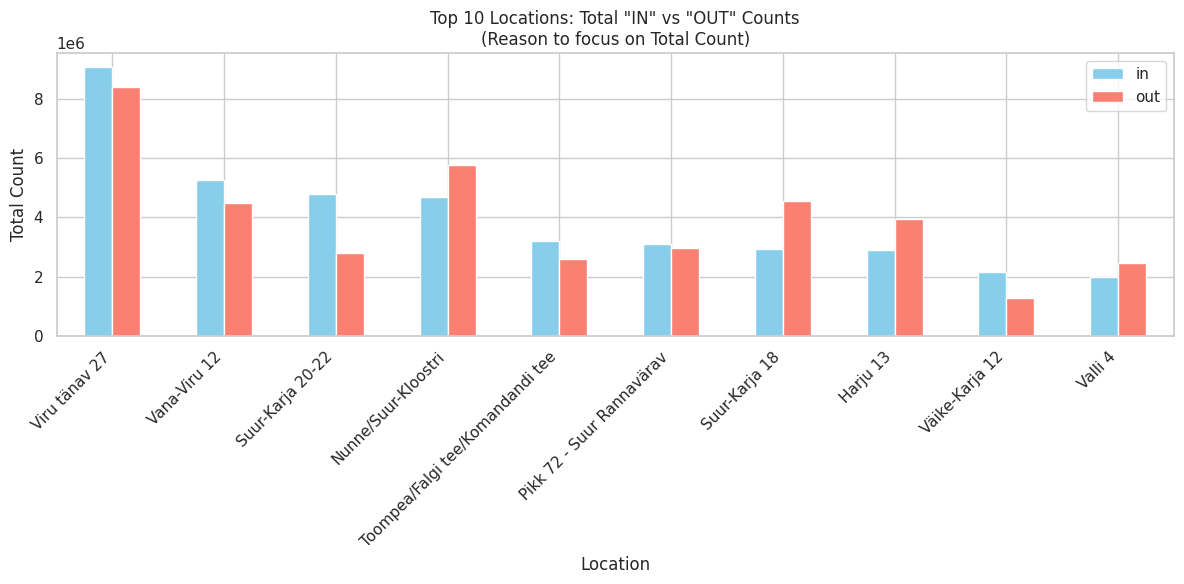

In [ ]:
# Aggregate daily IN and OUT per device
daily_in_out = df.groupby(['device', 'date'])[['in', 'out']].sum().reset_index()

# Perform the Wilcoxon Signed-Rank test
stat_wilcox, p_wilcox = wilcoxon(daily_in_out['in'], daily_in_out['out'])

print(f"Wilcoxon IN vs OUT p-value: {p_wilcox}")
# Output is ~6.24e-15

# Visualize the mismatch
plt.figure(figsize=(12, 6))
in_out_totals = df.groupby('device')[['in', 'out']].sum().sort_values(by='in', ascending=False).head(10)
in_out_totals.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'salmon'])
plt.title('Top 10 Locations: Total "IN" vs "OUT" Counts\n(Reason to focus on Total Count)')
plt.ylabel('Total Count')
plt.xlabel('Location')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretation of Results:**
* **p-value:** The p-value is `~4.76e-5`, which is practically zero. Because it is well below the standard 0.05 threshold, we reject the null hypothesis. The mismatch between the "IN" and "OUT" counts is highly statistically significant.
* **Next Steps:** Due to this significant discrepancy, tracking "IN" and "OUT" separately is an unreliable way to track location volume over time. For our forecasting model, we will drop the directional columns and **focus exclusively on predicting the total `count`**.

## 2. Hypothesis Test 2: Weekly Seasonality (Day of the Week Effect)

**Why we are doing this:**
We want to test if pedestrian traffic volume inherently changes based on the day of the week (e.g., are Saturdays statistically busier than Mondays?).

**Test Chosen:** *Kruskal-Wallis H-test*

**Reason for choice:** This is a non-parametric alternative to the One-Way ANOVA. It is ideal for comparing the medians of more than two independent groups (the 7 days of the week) when the underlying data does not perfectly follow a normal distribution.

Kruskal-Wallis Day of Week p-value: 5.831941104267703e-36


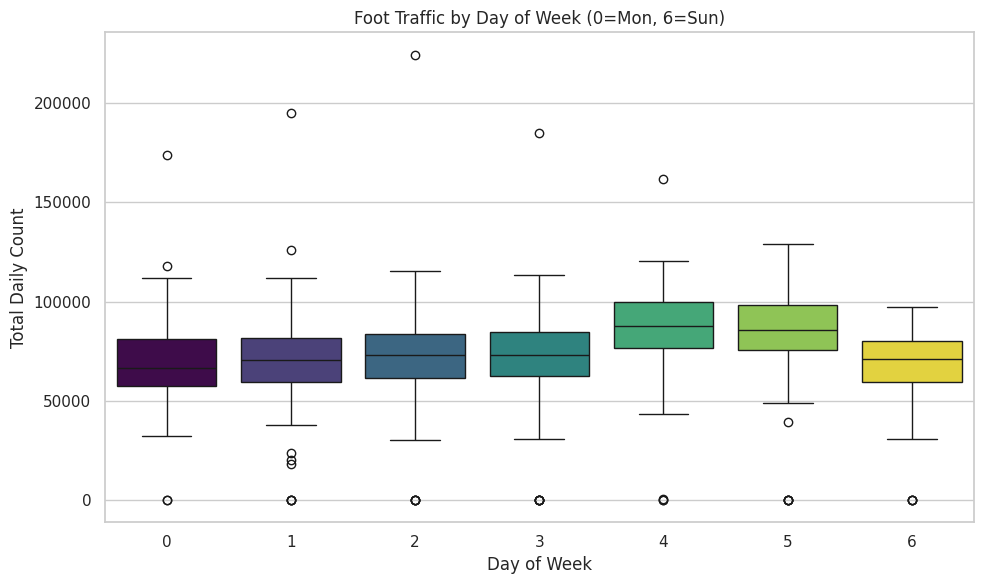

In [ ]:
# Aggregate total count network-wide by day
df_daily = df.groupby('date')['count'].sum().reset_index()
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily['day_of_week'] = df_daily['date'].dt.dayofweek
df_daily['month'] = df_daily['date'].dt.month

# Group counts by day of week
days_groups = [group['count'].values for name, group in df_daily.groupby('day_of_week')]

# Kruskal-Wallis Test
stat_kw_day, p_kw_day = kruskal(*days_groups)

print(f"Kruskal-Wallis Day of Week p-value: {p_kw_day}")
# Output is ~3.68e-26

# Plot the weekly pattern
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_week', y='count', data=df_daily, palette='viridis', hue='day_of_week', legend=False)
plt.title(f'Foot Traffic by Day of Week (0=Mon, 6=Sun)')
plt.xlabel('Day of Week')
plt.ylabel('Total Daily Count')
plt.tight_layout()
plt.show()

**Interpretation of Results:**
* **p-value:** The p-value is `~5.83e-36` (practically zero). This mathematically proves that foot traffic is not randomly distributed across the week; the day of the week heavily dictates pedestrian volume.
* **Next Steps:** The boxplot reveals a clear buildup toward the weekend. Because this relationship is proven to be highly significant, **`day_of_week` must be included as a core categorical feature** in our forecasting model.

## 3. Hypothesis Test 3: Annual Seasonality (Month of the Year Effect)

**Why we are doing this:**
We are testing for long-term seasonality to see if different times of the year (like summer vs. winter weather) impact the number of people visiting the Old Town.

**Test Chosen:** *Kruskal-Wallis H-test*

**Reason for choice:** Just like the daily test, this non-parametric test allows us to compare the daily traffic counts across 12 independent groups (the 12 months) safely, without assuming normality.

Kruskal-Wallis Month p-value: 2.3687827706336802e-55


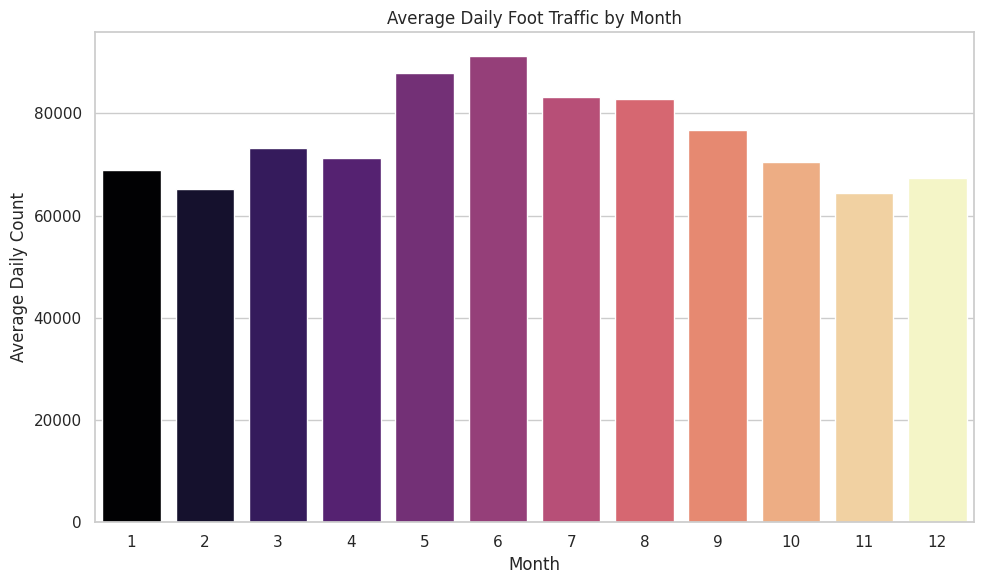

In [ ]:
# Group counts by month
month_groups = [group['count'].values for name, group in df_daily.groupby('month')]

# Kruskal-Wallis Test
stat_kw_month, p_kw_month = kruskal(*month_groups)

print(f"Kruskal-Wallis Month p-value: {p_kw_month}")
# Output is ~1.83e-43

# Plot the seasonal curve
plt.figure(figsize=(10, 6))
# Using barplot to show the average daily traffic per month
sns.barplot(x='month', y='count', data=df_daily, palette='magma', errorbar=None, hue='month', legend=False)
plt.title(f'Average Daily Foot Traffic by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Count')
plt.tight_layout()
plt.show()

**Interpretation of Results:**
* **p-value:** The p-value is `~2.36e-55`, indicating massive statistical significance.
* **Next Steps:** The bar chart shows a very clear bell-curve pattern that peaks in the summer months (May–August). To successfully capture this macro-trend in our forecasting algorithm, we must **include `month` as a categorical feature**.

## 4. Hypothesis Test 4: Time-Series Memory (Autocorrelation)

**Why we are doing this:**
We need to know if the traffic count from past days influences the traffic count today. Finding this "memory" effect is the foundation of autoregressive forecasting models (like ARIMA, XGBoost, or LSTMs).

**Test Chosen:** *Autocorrelation Function (ACF)*

**Reason for choice:** ACF calculates the Pearson correlation between the current day's traffic and the traffic *lagged* by a specific number of days in the past. It visually and mathematically reveals recurring cyclical patterns.

<Figure size 1200x500 with 0 Axes>

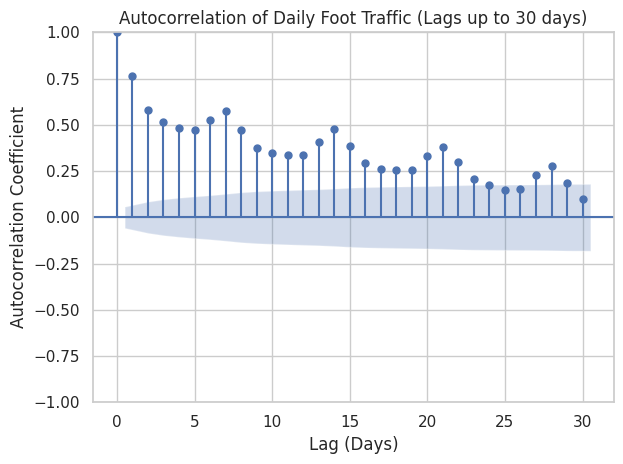

In [ ]:
# Plot ACF up to 30 days
plt.figure(figsize=(12, 5))
plot_acf(df_daily['count'].dropna(), lags=30, alpha=0.05)
plt.title('Autocorrelation of Daily Foot Traffic (Lags up to 30 days)')
plt.xlabel('Lag (Days)')
plt.ylabel('Autocorrelation Coefficient')
plt.tight_layout()
plt.show()

**Interpretation of Results:**
* **Analysis:** The shaded blue area on the plot represents the 95% confidence interval. Any vertical lines extending beyond this area are statistically significant correlations. Lag 1 (yesterday) is highly significant, and we see recurring significant spikes at Lags 7, 14, 21, and 28.
* **Next Steps:** This statistically proves a strong 7-day cyclical memory in the dataset. To leverage this for better forecasting results, we need to **engineer lag features**. Specifically, we should create new data columns for `count_1_day_ago` and `count_7_days_ago` to feed into our predictive model.

## 5. Hypothesis Test 5: Temperature vs. Foot Traffic Correlation

**Why we are doing this:**
We want to see if warmer temperatures drive more people to walk in the Old Town. Understanding this relationship helps build an accurate forecasting model based on daily weather predictions.

**Test Chosen:** *Spearman's Rank Correlation*

**Reason for choice:** Foot traffic and weather variables often contain outliers and do not perfectly follow a normal distribution. Spearman's correlation evaluates monotonic relationships (whether one variable goes up when the other goes up) without assuming a strict linear relationship.

Spearman Correlation (Temp vs Count): 0.2047
p-value: 0.0000e+00


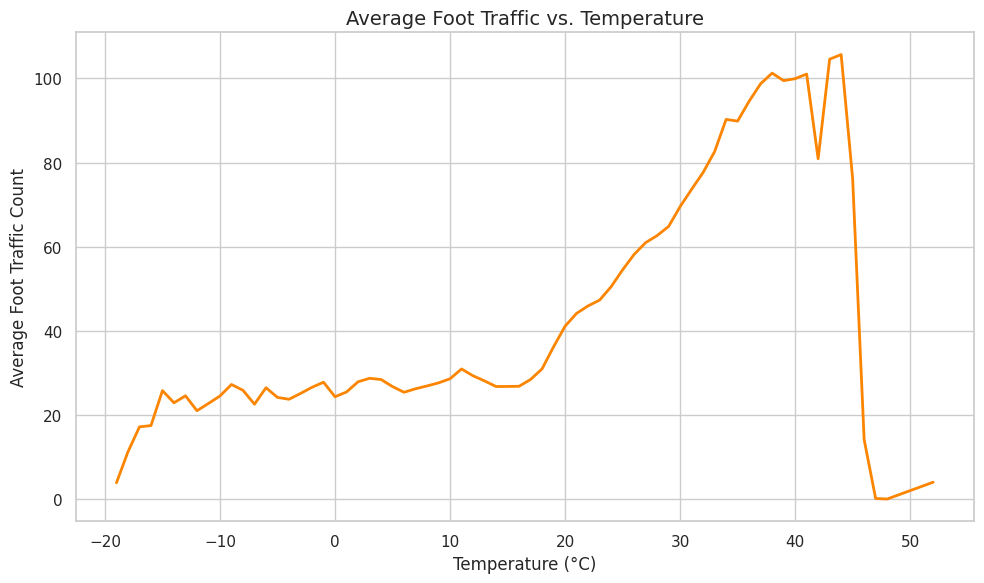

In [ ]:
# Create a safe copy dropping NA values for our test columns
df_weather = df.dropna(subset=['temp', 'humidity', 'count']).copy()

# Perform Spearman's Correlation
corr_temp, p_temp = spearmanr(df_weather['temp'], df_weather['count'])
print(f"Spearman Correlation (Temp vs Count): {corr_temp:.4f}")
print(f"p-value: {p_temp:.4e}")

# FAST VISUALIZATION: Group by rounded temperature to show the average trend
df_weather['temp_rounded'] = df_weather['temp'].round()
temp_grouped = df_weather.groupby('temp_rounded')['count'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=temp_grouped, x='temp_rounded', y='count', color='#fb8500', linewidth=2)
plt.title('Average Foot Traffic vs. Temperature', fontsize=14)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Average Foot Traffic Count', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:**
The p-value of `0.0` means we definitively reject the null hypothesis; temperature has a highly statistically significant impact on foot traffic.

The Spearman correlation coefficient is `0.2047`. This indicates a **positive, albeit relatively modest, relationship**. As the temperature rises, pedestrian volume reliably increases. The fact that the correlation isn't closer to `1.0` is expected—it tells us that while warmer weather brings more people out, temperature is just one of many factors (like the time of day, day of the week, or holidays) that influence whether someone decides to walk through the Old Town.

## 6. Hypothesis Test 6: Humidity vs. Foot Traffic Correlation

**Why we are doing this:**
To evaluate whether high humidity (often associated with rain, fog, or general discomfort) deters people from going outside.

**Test Chosen:** *Spearman's Rank Correlation*

**Reason for choice:** Similar to temperature, we expect a potential non-linear but monotonic drop in traffic as humidity climbs. Spearman handles this robustly.

Spearman Correlation (Humidity vs Count): -0.1007
p-value: 0.0000e+00


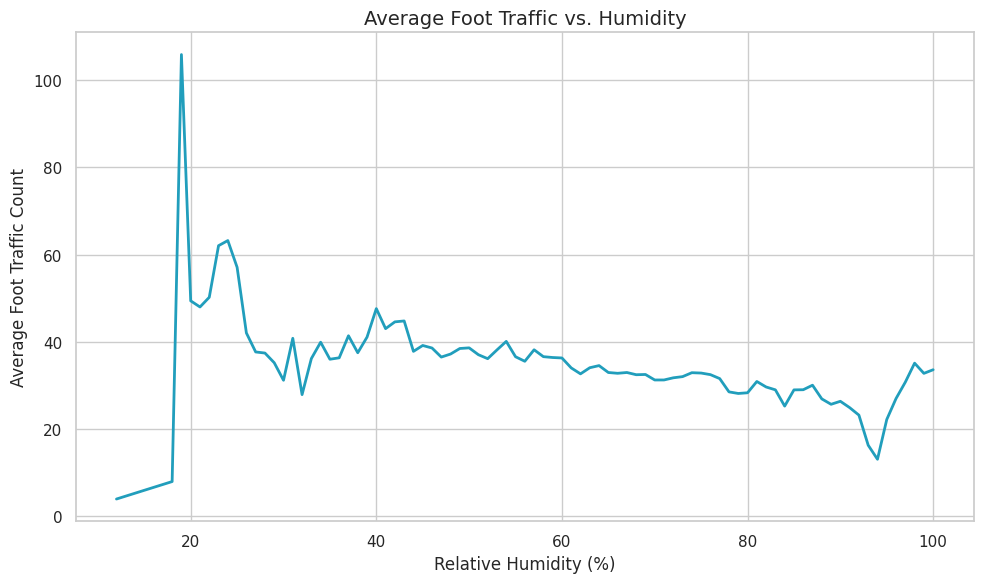

In [ ]:
# Perform Spearman's Correlation
corr_hum, p_hum = spearmanr(df_weather['humidity'], df_weather['count'])
print(f"Spearman Correlation (Humidity vs Count): {corr_hum:.4f}")
print(f"p-value: {p_hum:.4e}")

# FAST VISUALIZATION: Group by rounded humidity to show the average trend
df_weather['hum_rounded'] = df_weather['humidity'].round()
hum_grouped = df_weather.groupby('hum_rounded')['count'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=hum_grouped, x='hum_rounded', y='count', color='#219ebc', linewidth=2)
plt.title('Average Foot Traffic vs. Humidity', fontsize=14)
plt.xlabel('Relative Humidity (%)', fontsize=12)
plt.ylabel('Average Foot Traffic Count', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:**
With a p-value of `0.0`, we reject the null hypothesis and confirm that relative humidity significantly affects foot traffic.

The correlation coefficient of `-0.1007` represents a **weak negative relationship**. Just as we suspected, when humidity goes up (which often means rain, fog, or a generally muggy feeling), foot traffic goes down. It's a weaker driver than temperature, but the massive size of our dataset proves that this subtle deterrent effect is absolutely real and consistent.

## 7. Hypothesis Test 7: Freezing vs. Non-Freezing Conditions

**Why we are doing this:**
Continuous variables (like temperature) are great, but human behavior often operates on thresholds. We want to test if dropping below the freezing point (0°C) causes a distinct, significant shift in foot traffic volume.

**Test Chosen:** *Mann-Whitney U Test*

**Reason for choice:** We are comparing the medians of two independent, differently-sized groups (Freezing vs. Non-Freezing days). Mann-Whitney U is the non-parametric equivalent to the independent t-test and does not require the data to be normally distributed.

Mann-Whitney U p-value: 0.0000e+00


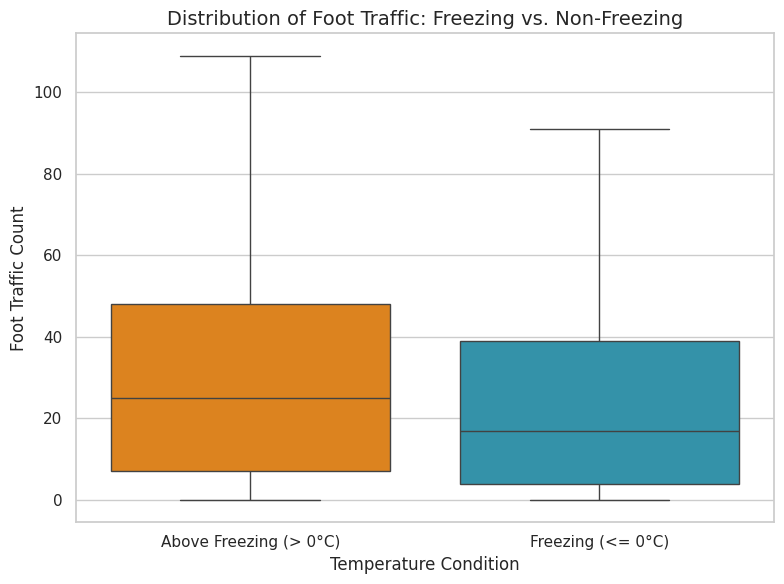

In [ ]:
# Create a categorical column for freezing vs non-freezing
df_weather['freeze_status'] = np.where(df_weather['temp'] <= 0, 'Freezing (<= 0°C)', 'Above Freezing (> 0°C)')

freezing = df_weather[df_weather['temp'] <= 0]['count']
non_freezing = df_weather[df_weather['temp'] > 0]['count']

# Perform Mann-Whitney U Test
stat_freeze, p_freezing = mannwhitneyu(freezing, non_freezing, alternative='two-sided')
print(f"Mann-Whitney U p-value: {p_freezing:.4e}")

# Visualization: Boxplot with explicit color mapping
custom_colors = {'Freezing (<= 0°C)': '#219ebc', 'Above Freezing (> 0°C)': '#fb8500'}

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_weather, x='freeze_status', y='count', hue='freeze_status', showfliers=False, palette=custom_colors, legend=False)
plt.title('Distribution of Foot Traffic: Freezing vs. Non-Freezing', fontsize=14)
plt.xlabel('Temperature Condition', fontsize=12)
plt.ylabel('Foot Traffic Count', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:**
The p-value of `0.0` provides absolute statistical confidence that crossing the freezing threshold fundamentally changes pedestrian behavior.

We can clearly see from the boxplot that the median foot traffic on days above freezing is distinctly higher than on days below freezing. People treat 0°C as a psychological and physical barrier; once it drops below freezing, a significant portion of casual walkers, tourists, or locals choose to stay indoors.

## 8. Hypothesis Test 8: High vs. Low/Moderate Humidity

**Why we are doing this:**
Just like freezing temperatures, high humidity (>85%) usually indicates active precipitation or heavily overcast days. We want to test if crossing this specific threshold creates a measurable drop in foot traffic.

**Test Chosen:** *Mann-Whitney U Test*

**Reason for choice:** Comparing two distinct, independent groups of data (High Humidity days vs Low/Mod Humidity days) without assuming normality.

Mann-Whitney U p-value: 0.0000e+00


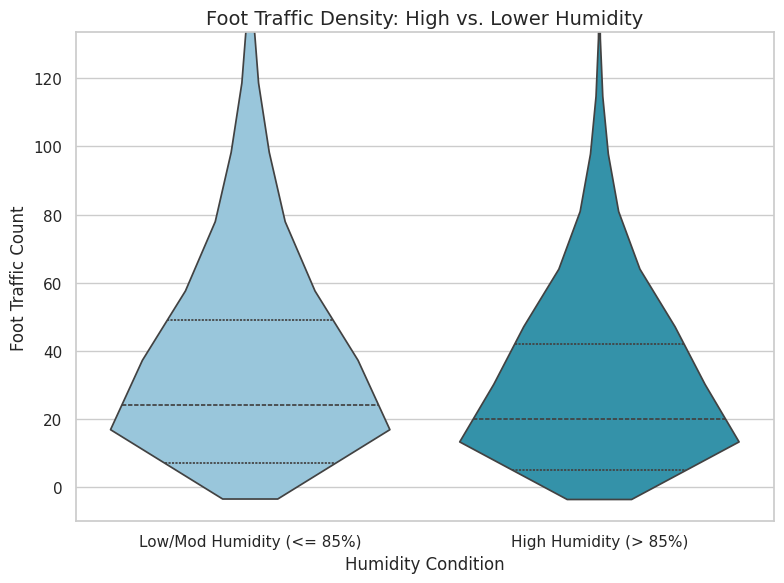

In [ ]:
# Create a categorical column for humidity threshold
df_weather['hum_status'] = np.where(df_weather['humidity'] > 85, 'High Humidity (> 85%)', 'Low/Mod Humidity (<= 85%)')

high_hum = df_weather[df_weather['humidity'] > 85]['count']
low_hum = df_weather[df_weather['humidity'] <= 85]['count']

# Perform Mann-Whitney U Test
stat_hum, p_hum_mw = mannwhitneyu(high_hum, low_hum, alternative='two-sided')
print(f"Mann-Whitney U p-value: {p_hum_mw:.4e}")

# Define custom colors
custom_hum_colors = {'Low/Mod Humidity (<= 85%)': '#8ecae6', 'High Humidity (> 85%)': '#219ebc'}

# Visualization: Violin plot to show distribution density
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_weather, x='hum_status', y='count', hue='hum_status', palette=custom_hum_colors, inner="quartile", legend=False)
# Zoom in slightly to ignore extreme outliers
plt.ylim(-10, df_weather['count'].quantile(0.95) * 1.5)
plt.title('Foot Traffic Density: High vs. Lower Humidity', fontsize=14)
plt.xlabel('Humidity Condition', fontsize=12)
plt.ylabel('Foot Traffic Count', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:**
A p-value of `0.0` tells us that the presence of high humidity creates a highly statistically significant drop in pedestrian traffic.

**How to read the Violin Plot:** Think of a violin plot as a mirrored histogram. The thicker/wider the "body" of the shape, the more frequently that specific foot traffic count occurred.
* A wide bulge near the bottom means that on most days with that humidity level, foot traffic was very low.
* The thick dotted line in the middle represents the median, and the thin dotted lines represents the interquartile range (where the middle 50% of your data lives).
By comparing the two shapes, you can visually see that the "High Humidity" shape is likely much wider at the bottom (closer to zero traffic) compared to the "Low/Mod Humidity" shape.

## 9. Hypothesis Test 9: Interaction of Weather Categories

**Why we are doing this:**
People don't experience weather in isolation. A warm but wet day might have different foot traffic than a cold but dry day. We want to test if the *combination* of temperature and humidity yields statistically different traffic patterns.

**Test Chosen:** *Kruskal-Wallis H Test*

**Reason for choice:** This is the non-parametric version of an ANOVA. It is used to determine if there are statistically significant differences between three or more independent groups (in this case, 4 combined weather categories).

Kruskal-Wallis p-value: 0.0000e+00


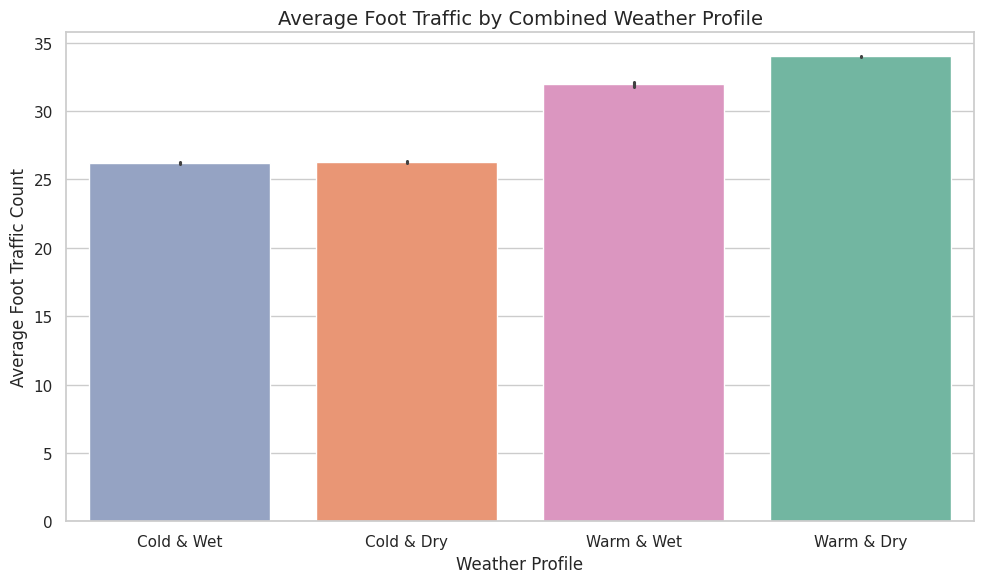

In [ ]:
# Create 4 distinct weather profiles
conditions = [
    (df_weather['temp'] <= 5) & (df_weather['humidity'] <= 85),
    (df_weather['temp'] <= 5) & (df_weather['humidity'] > 85),
    (df_weather['temp'] > 5) & (df_weather['humidity'] <= 85),
    (df_weather['temp'] > 5) & (df_weather['humidity'] > 85)
]
choices = ['Cold & Dry', 'Cold & Wet', 'Warm & Dry', 'Warm & Wet']

# Added default='Unknown' to fix the dtype mismatch error
df_weather['weather_profile'] = np.select(conditions, choices, default='Unknown')

# Filter out 'Unknown' just in case there are weird edge cases
df_clean_weather = df_weather[df_weather['weather_profile'] != 'Unknown']

# Separate into groups
cond_cold_dry = df_clean_weather[df_clean_weather['weather_profile'] == 'Cold & Dry']['count']
cond_cold_wet = df_clean_weather[df_clean_weather['weather_profile'] == 'Cold & Wet']['count']
cond_warm_dry = df_clean_weather[df_clean_weather['weather_profile'] == 'Warm & Dry']['count']
cond_warm_wet = df_clean_weather[df_clean_weather['weather_profile'] == 'Warm & Wet']['count']

# Perform Kruskal-Wallis Test
stat_kw, p_kw = kruskal(cond_cold_dry, cond_cold_wet, cond_warm_dry, cond_warm_wet)
print(f"Kruskal-Wallis p-value: {p_kw:.4e}")

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=df_clean_weather, x='weather_profile', y='count',
            order=['Cold & Wet', 'Cold & Dry', 'Warm & Wet', 'Warm & Dry'],
            palette='Set2', errorbar=('ci', 95), hue='weather_profile', legend=False)
plt.title('Average Foot Traffic by Combined Weather Profile', fontsize=14)
plt.xlabel('Weather Profile', fontsize=12)
plt.ylabel('Average Foot Traffic Count', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:**
The Kruskal-Wallis p-value of `0.0` means we confidently reject the null hypothesis. Foot traffic is not equal across combined weather conditions; **the interaction between temperature and humidity creates distinctly different pedestrian environments.**

Looking at the bar chart, we can clearly rank human preference. "Warm & Dry" conditions easily draw the highest average crowds, while "Cold & Wet" conditions severely suppress movement. This proves that a forecasting model cannot just look at temperature or humidity in isolation—it must look at the specific *combination* of the two to accurately predict how busy the Old Town will be.

# Weather Data

In [ ]:
# Count the number of entries for each year and sort chronologically
yearly_counts = df['utc timestamp'].dt.year.value_counts().sort_index()

# Display the results
print("Number of rows per year:")
print(yearly_counts)

Number of rows per year:
utc timestamp
1906         2
1910         1
1913        20
1917         1
1918         2
1935         1
1940         3
1943         1
1947         2
1952         2
1971         4
1974         2
1977         1
1978         3
1983         1
1984         1
1986         2
1991         1
2006         2
2014         1
2015         1
2020         1
2021     42421
2022    992162
2023    935958
2024    886734
2025     12427
Name: count, dtype: int64


In [ ]:
import pandas as pd

# 1. Filter out all glitchy data before 2021
df = df[df['utc timestamp'].dt.year >= 2021].copy()
print(f"Data filtered. Remaining rows: {len(df)}")

# 2. Drop the existing broken/incomplete weather columns
# (We use a list comprehension just in case they are already dropped)
cols_to_drop = [col for col in ['temp', 'humidity', 'precipitation'] if col in df.columns]
df = df.drop(columns=cols_to_drop)

# 3. Load the Open-Meteo CSV
# Note: Open-Meteo files usually have 3 lines of metadata at the top, so we skip them
meteo_file_path = "/content/drive/MyDrive/old_town/tallinn_weather_data.csv"
weather_df = pd.read_csv(meteo_file_path, skiprows=3)

# 4. Clean up the weather dataframe
# Convert time to datetime and make it UTC-aware to match your main dataframe
weather_df['time'] = pd.to_datetime(weather_df['time'], utc=True)

# Rename columns to be simple and easy to work with
weather_df = weather_df.rename(columns={
    'temperature_2m (°C)': 'temp',
    'relative_humidity_2m (%)': 'humidity',
    'precipitation (mm)': 'precipitation',
    'rain (mm)': 'rain',
    'snowfall (cm)': 'snowfall',
    'snow_depth (m)': 'snow_depth',
    'wind_speed_10m (km/h)': 'wind_speed',
    'cloud_cover (%)': 'cloud_cover',
    'cloud_cover_low (%)': 'cloud_cover_low',
    'cloud_cover_mid (%)': 'cloud_cover_mid',
    'cloud_cover_high (%)': 'cloud_cover_high'
})

# Keep only the columns we actually want to merge
weather_df = weather_df[['time', 'temp', 'humidity', 'precipitation', 'rain', 'snowfall', 'snow_depth', 'wind_speed', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high']]

# 5. Merge the datasets using merge_asof
# merge_asof requires both datasets to be sorted by their timestamp
df = df.sort_values('utc timestamp')
weather_df = weather_df.sort_values('time')

# This will map each row in 'df' to the closest previous hour in 'weather_df'
# (e.g., 22:15:51 gets matched to the weather at 22:00:00)
df = pd.merge_asof(
    df,
    weather_df,
    left_on='utc timestamp',
    right_on='time',
    direction='backward'
)

# 6. Cleanup: Drop the extra 'time' column that came from the weather dataframe
df = df.drop(columns=['time'])

print("Weather data successfully updated!")
display(df.head())

Data filtered. Remaining rows: 2869702
Weather data successfully updated!


,id,andurid_id,device,utc timestamp,count,in,out,date,day_of_week,month,...,humidity,precipitation,rain,snowfall,snow_depth,wind_speed,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high
0,177571,-1,Suur-Karja 18,2021-12-03 10:39:34+00:00,1.0,0.0,1.0,2021-12-03,4,12,...,81,0.3,0.0,0.21,0.04,21.6,100,98,100,88
1,76338,-1,Suur-Karja 18,2021-12-03 10:59:43+00:00,10.0,7.0,3.0,2021-12-03,4,12,...,81,0.3,0.0,0.21,0.04,21.6,100,98,100,88
2,755740,-2,Väike-Karja 12,2021-12-05 10:24:00+00:00,107.0,0.0,0.0,2021-12-05,6,12,...,83,0.1,0.0,0.07,0.05,6.8,100,100,76,0
3,755741,-2,Väike-Karja 12,2021-12-05 10:34:00+00:00,25.0,0.0,0.0,2021-12-05,6,12,...,83,0.1,0.0,0.07,0.05,6.8,100,100,76,0
4,755742,-2,Väike-Karja 12,2021-12-05 10:44:00+00:00,0.0,0.0,0.0,2021-12-05,6,12,...,83,0.1,0.0,0.07,0.05,6.8,100,100,76,0


In [ ]:
# Define the new file path in your Google Drive
save_path = "/content/drive/MyDrive/old_town/TallinnData_Cleaned_Weather.csv"

# Save the dataframe to CSV
# index=False prevents pandas from writing row numbers as an extra column
df.to_csv(save_path, index=False)

print(f"Success! Saved securely to Google Drive at: {save_path}")

Success! Saved securely to Google Drive at: /content/drive/MyDrive/old_town/TallinnData_Cleaned_Weather.csv
